<a href="https://colab.research.google.com/github/Napassornmp/Project_Bank-Analysis/blob/main/Project_Bank_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Analysis

In [1]:
import pandas as pd

In [2]:
#import data
data = pd.read_csv('/content/drive/MyDrive/DataforProject/bank (2).csv')

In [3]:
data.shape

(11162, 17)

In [4]:
data.columns
data.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


Identify Categorical columns and Numeric columns

In [5]:
object_cols = data.select_dtypes(include='object').columns
numeric_cols = data.select_dtypes(include='int').columns

In [6]:
print(object_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')


In [7]:
cat_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month','poutcome']
num_columns = ['balance', 'day','duration', 'campaign', 'pdays', 'previous']

# Verify the features distribution in the dataset.

/tmp/ipython-input-3777305990.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set3')
/tmp/ipython-input-3777305990.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set3')
/tmp/ipython-input-3777305990.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set3')
/tmp/ipython-input-3777305990.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend

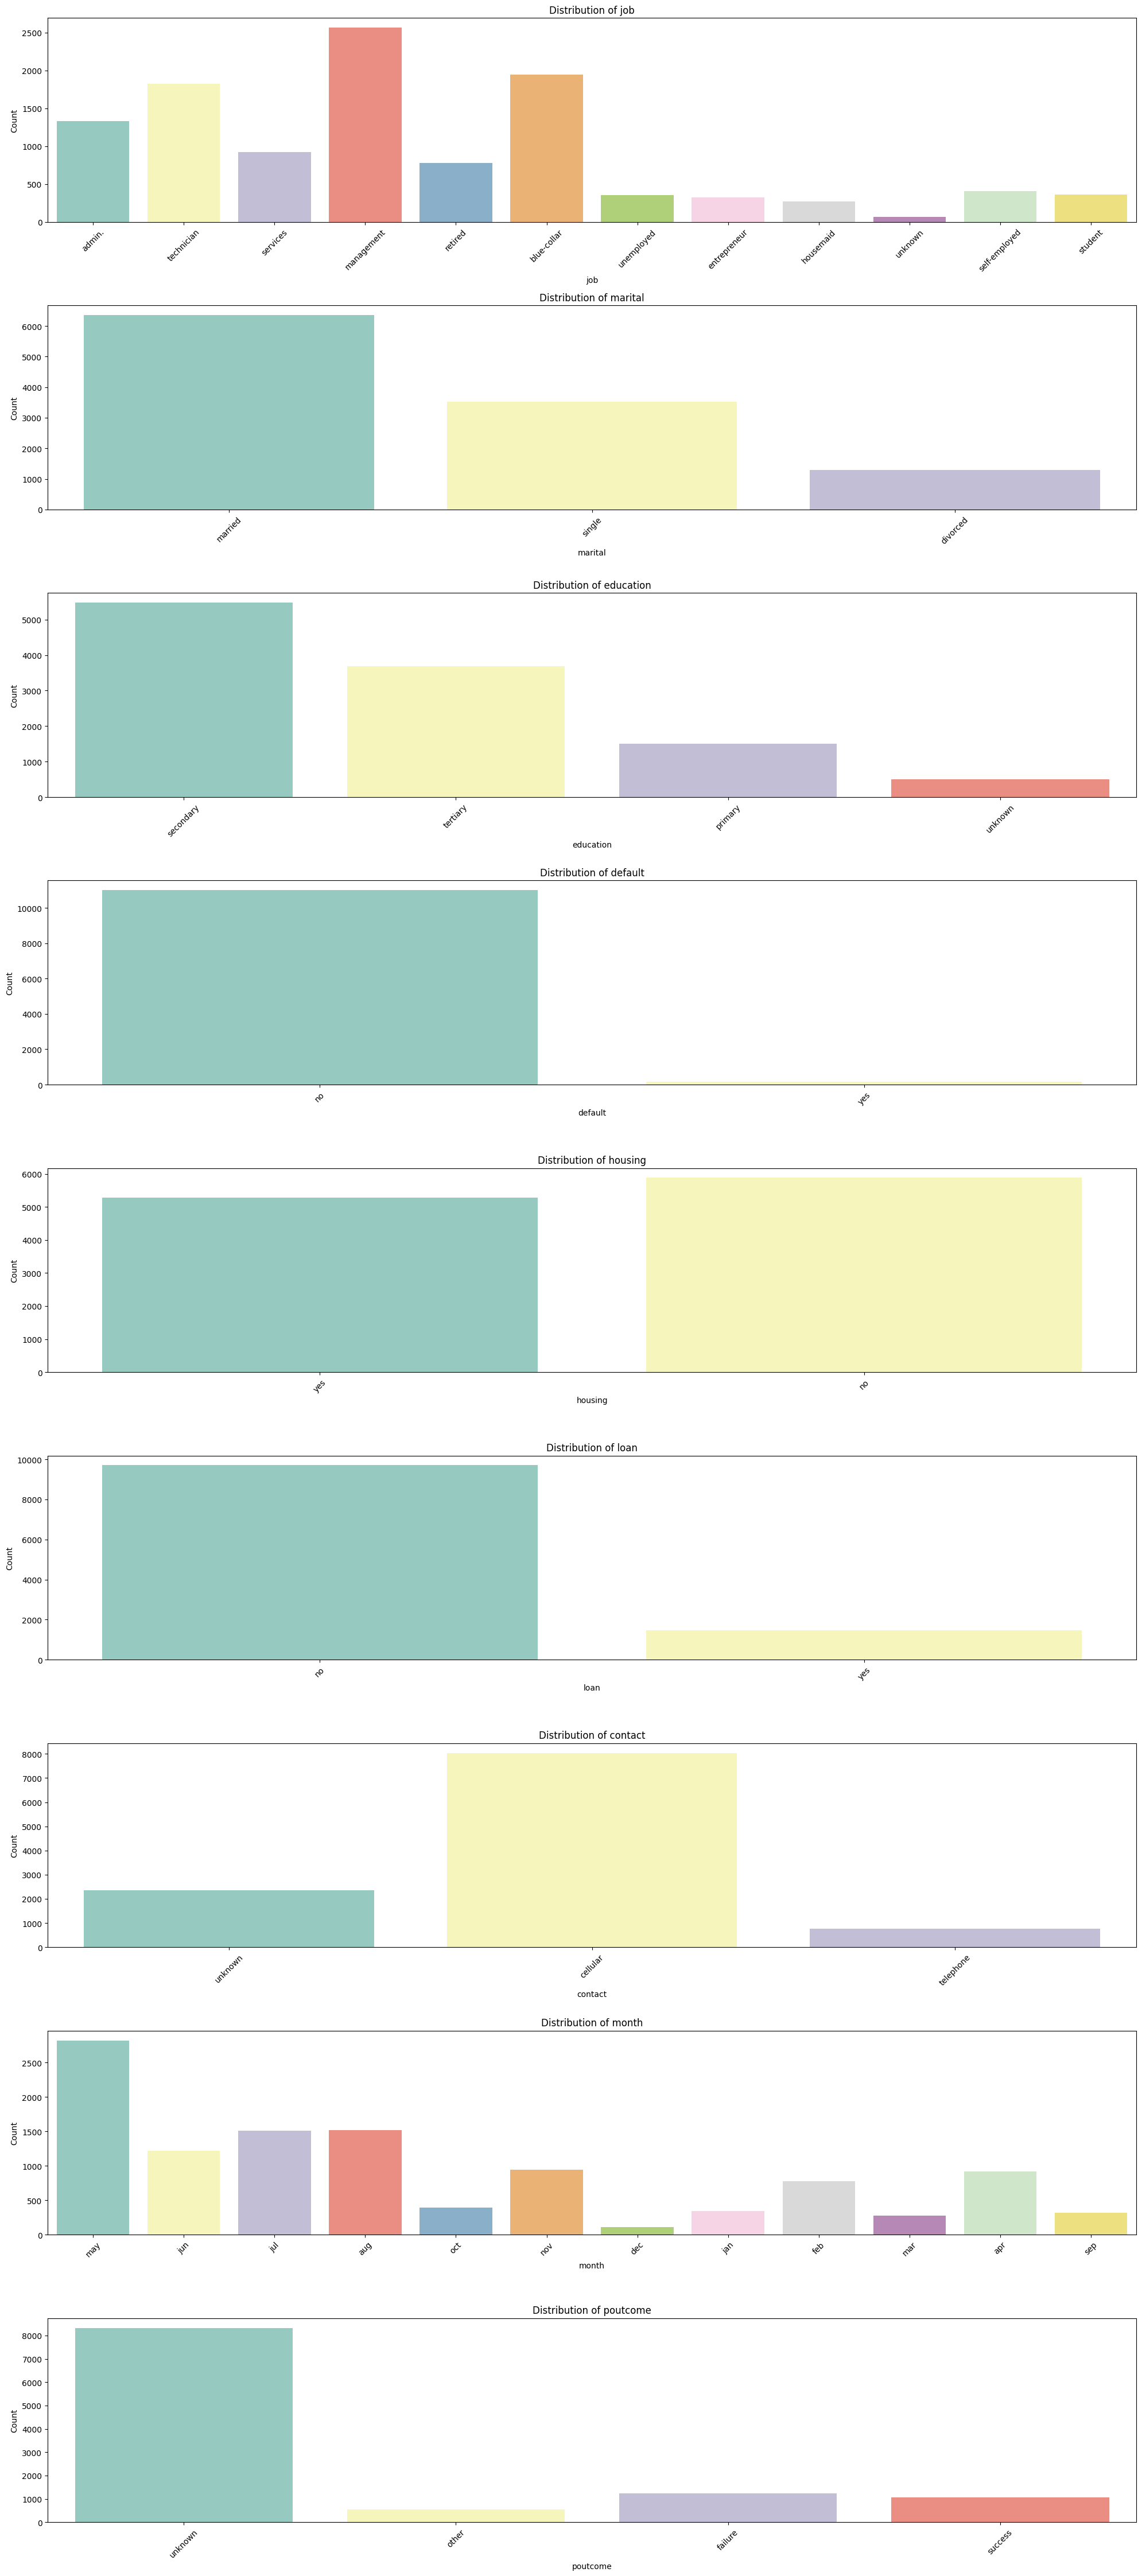

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# สมมติ categorical columns


plt.figure(figsize=(20, 5*len(cat_columns)))

for i, col in enumerate(cat_columns):
    plt.subplot(len(cat_columns), 1, i+1)
    sns.countplot(x=col, data=data, palette='Set3')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)  # หมุนชื่อ category ถ้ายาว
plt.tight_layout()
plt.show()


# Verify the class distribution in the dataset.
We have class No larger than class Yes.

/tmp/ipython-input-3290042396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit', data=data, palette='Set2')


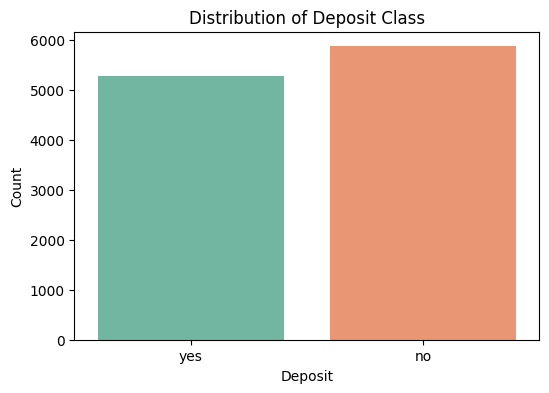

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=data, palette='Set2')

plt.title('Distribution of Deposit Class')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.show()

In [10]:
data


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


# Explore missing value

In [11]:
data.isnull().sum() #Check null values

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


# Data Manipulation
## Split Class and Features

In [12]:
from sklearn.model_selection import train_test_split

feature = data.drop('deposit', axis=1)
y = data['deposit']




## Converse Categorical column features to bool ( Dummy variable )



In [13]:
df_dummy = pd.get_dummies(feature, drop_first=True)
print("Data after dummy encoding:")
print(df_dummy)

Data after dummy encoding:
       age  balance  day  duration  campaign  pdays  previous  \
0       59     2343    5      1042         1     -1         0   
1       56       45    5      1467         1     -1         0   
2       41     1270    5      1389         1     -1         0   
3       55     2476    5       579         1     -1         0   
4       54      184    5       673         2     -1         0   
...    ...      ...  ...       ...       ...    ...       ...   
11157   33        1   20       257         1     -1         0   
11158   39      733   16        83         4     -1         0   
11159   32       29   19       156         2     -1         0   
11160   43        0    8         9         2    172         5   
11161   34        0    9       628         1     -1         0   

       job_blue-collar  job_entrepreneur  job_housemaid  ...  month_jul  \
0                False             False          False  ...      False   
1                False             False  

In [14]:
print(df_dummy.dtypes)


age                    int64
balance                int64
day                    int64
duration               int64
campaign               int64
pdays                  int64
previous               int64
job_blue-collar         bool
job_entrepreneur        bool
job_housemaid           bool
job_management          bool
job_retired             bool
job_self-employed       bool
job_services            bool
job_student             bool
job_technician          bool
job_unemployed          bool
job_unknown             bool
marital_married         bool
marital_single          bool
education_secondary     bool
education_tertiary      bool
education_unknown       bool
default_yes             bool
housing_yes             bool
loan_yes                bool
contact_telephone       bool
contact_unknown         bool
month_aug               bool
month_dec               bool
month_feb               bool
month_jan               bool
month_jul               bool
month_jun               bool
month_mar     

In [15]:
print(df_dummy.isna().sum())
#Check null values

age                    0
balance                0
day                    0
duration               0
campaign               0
pdays                  0
previous               0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_married        0
marital_single         0
education_secondary    0
education_tertiary     0
education_unknown      0
default_yes            0
housing_yes            0
loan_yes               0
contact_telephone      0
contact_unknown        0
month_aug              0
month_dec              0
month_feb              0
month_jan              0
month_jul              0
month_jun              0
month_mar              0
month_may              0
month_nov              0
month_oct              0
month_sep              0
poutcome_other         0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df_dummy, y, test_size=0.2, random_state=42
)

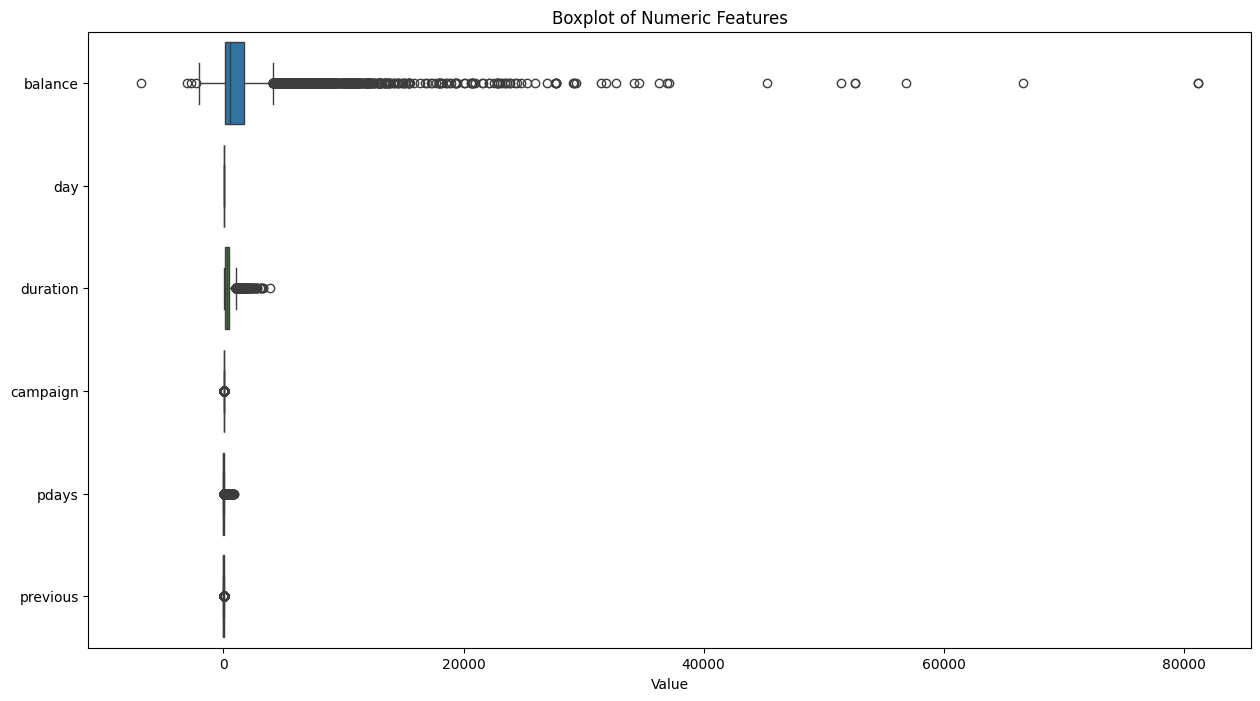

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
sns.boxplot(data=data[num_columns], orient='h')  # orient='h' ให้เป็นแนวนอน
plt.title('Boxplot of Numeric Features')
plt.xlabel('Value')
plt.show()

# Classification

# Naive Bayes
Identify bank customers who decide to deposit or not by Naive Bayes classifier method.

In [18]:
df_dummy

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
11158,39,733,16,83,4,-1,0,False,False,False,...,False,True,False,False,False,False,False,False,False,True
11159,32,29,19,156,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11160,43,0,8,9,2,172,5,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [19]:
X_train


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
3955,28,5741,10,1042,5,200,3,False,False,False,...,False,False,False,False,False,False,True,False,False,False
11150,34,355,21,314,3,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5173,48,201,10,594,1,91,1,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3017,53,1961,15,351,1,-1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
2910,53,1624,11,166,3,97,7,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,47,761,11,80,2,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
5191,28,159,16,449,2,33,4,False,False,False,...,False,False,False,False,True,False,False,False,True,False
5390,35,1144,20,197,13,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
860,51,746,25,372,5,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True


# GaussianNB

In [20]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)


GaussianNB()

In [21]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7398119122257053
              precision    recall  f1-score   support

          no       0.70      0.88      0.78      1166
         yes       0.82      0.59      0.68      1067

    accuracy                           0.74      2233
   macro avg       0.76      0.73      0.73      2233
weighted avg       0.76      0.74      0.73      2233

[[1024  142]
 [ 439  628]]


# Confusion Matrix Visualization

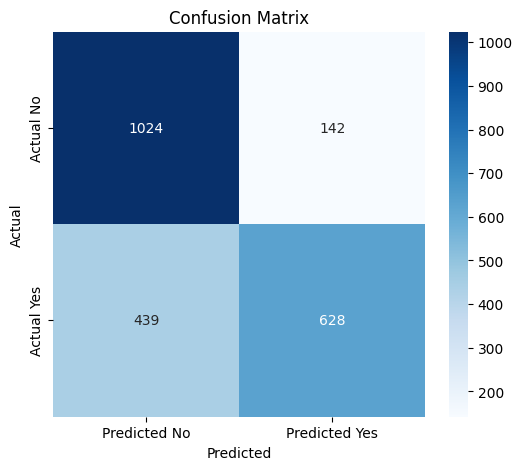

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# K-means

In [24]:
df_dummy

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
11158,39,733,16,83,4,-1,0,False,False,False,...,False,True,False,False,False,False,False,False,False,True
11159,32,29,19,156,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11160,43,0,8,9,2,172,5,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [25]:
num_columns = ['age','balance', 'day','duration', 'campaign', 'pdays', 'previous']

## Scaling numeric values

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_dummy[num_columns])

# แปลงกลับเป็น DataFrame
df_dummy[num_columns] = pd.DataFrame(scaled_array, columns=num_columns, index=df_dummy.index)

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df_dummy)
labels = kmeans.labels_  # cluster labels


In [28]:
df_dummy['cluster'] = labels
print(df_dummy['cluster'].value_counts())

cluster
1    8457
0    2705
Name: count, dtype: int64


In [29]:
df_dummy

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,cluster
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260,True,False,False,...,False,False,False,False,False,False,False,False,True,1
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260,False,False,False,...,True,False,False,False,False,False,False,False,True,1
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260,False,False,False,...,False,False,False,False,False,False,False,False,True,1
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332,False,False,False,...,False,False,True,False,False,False,False,False,False,0


/tmp/ipython-input-430830752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df_dummy, palette='Set2')


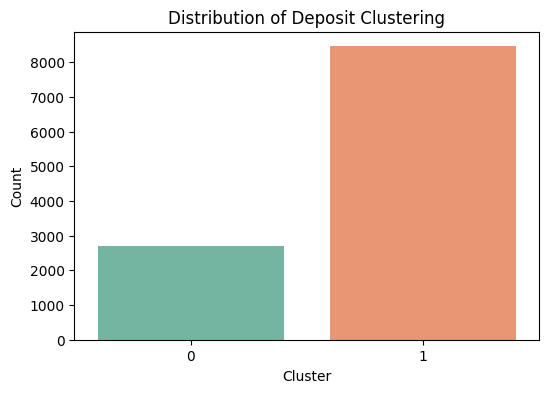

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='cluster', data=df_dummy, palette='Set2')

plt.title('Distribution of Deposit Clustering')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In the future customers tend to be cluster 1 (Deposit = No) ,We need to active strategies.

# Compare the clustering efficiency of K-means by Actual class

In [31]:
df_dummy

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,cluster
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260,False,False,False,...,False,False,True,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260,True,False,False,...,False,False,False,False,False,False,False,False,True,1
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260,False,False,False,...,True,False,False,False,False,False,False,False,True,1
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260,False,False,False,...,False,False,False,False,False,False,False,False,True,1
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332,False,False,False,...,False,False,True,False,False,False,False,False,False,0


In [32]:
df_dummy['deposit'] = data['deposit'].values

In [33]:
df_dummy

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,cluster,deposit
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260,False,False,False,...,False,True,False,False,False,False,False,True,1,yes
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260,False,False,False,...,False,True,False,False,False,False,False,True,1,yes
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260,False,False,False,...,False,True,False,False,False,False,False,True,1,yes
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260,False,False,False,...,False,True,False,False,False,False,False,True,1,yes
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260,False,False,False,...,False,True,False,False,False,False,False,True,1,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260,True,False,False,...,False,False,False,False,False,False,False,True,1,no
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260,False,False,False,...,False,False,False,False,False,False,False,True,1,no
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260,False,False,False,...,False,False,False,False,False,False,False,True,1,no
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332,False,False,False,...,False,True,False,False,False,False,False,False,0,no


In [34]:
df_Kmeans = pd.crosstab(df_dummy['cluster'], data['deposit'])

In [35]:
df_Kmeans

deposit,no,yes
cluster,,
0,890,1815
1,4983,3474


Most customers in Cluster 0 have Deposit = Yes

Most customers in Cluster 1 have Deposit = No


# Conclusion
Based on the results from the K-means clustering analysis,

Bank customers identified in Cluster 0 tend to make deposits. Therefore, we can design and apply suitable offerings specifically for customers in this group in the future whether their current deposit status is “Yes” or “No.”

On the other hands, Customers in Cluster 1 are more likely to remain non-depositors the bank should activate proactive strategies

# “Filter customers in Cluster 1 (Class No) who have non-deposit behavior but an actual current status is Yes. This implies they may cancel their deposits soon.”

In [36]:
# กรองลูกค้าที่ Deposit = 'yes' แต่อยู่ Cluster 1
cluster1_yes = df_dummy[(df_dummy['cluster'] == 1) & (df_dummy['deposit'] == 'yes')]

# แสดงผลบางส่วน
print(cluster1_yes.head())


print("จำนวนลูกค้า Deposit = 'Yes' ใน Cluster 1:", len(cluster1_yes))


        age   balance       day  duration  campaign     pdays  previous  \
0  1.491505  0.252525 -1.265746  1.930226 -0.554168 -0.481184  -0.36326   
1  1.239676 -0.459974 -1.265746  3.154612 -0.554168 -0.481184  -0.36326   
2 -0.019470 -0.080160 -1.265746  2.929901 -0.554168 -0.481184  -0.36326   
3  1.155733  0.293762 -1.265746  0.596366 -0.554168 -0.481184  -0.36326   
4  1.071790 -0.416876 -1.265746  0.867171 -0.186785 -0.481184  -0.36326   

   job_blue-collar  job_entrepreneur  job_housemaid  ...  month_mar  \
0            False             False          False  ...      False   
1            False             False          False  ...      False   
2            False             False          False  ...      False   
3            False             False          False  ...      False   
4            False             False          False  ...      False   

   month_may  month_nov  month_oct  month_sep  poutcome_other  \
0       True      False      False      False           F

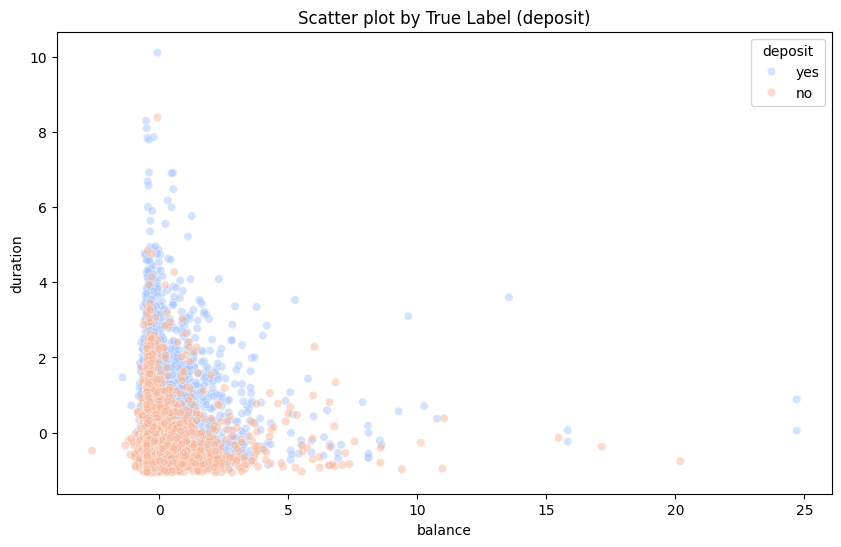

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_dummy['balance'],
    y=df_dummy['duration'],
    hue=data['deposit'],     # ใช้ label จริง
    palette='coolwarm',
    alpha=0.5
)
plt.title("Scatter plot by True Label (deposit)")
plt.show()


In [38]:
# groupby cluster และสรุปสถิติ
cluster_balance_stats = data.groupby(df_dummy['cluster'])['balance'].describe()
print(cluster_balance_stats)

          count         mean          std     min    25%    50%     75%  \
cluster                                                                   
0        2705.0  1823.277264  3761.818150 -1137.0  222.0  738.0  2140.0   
1        8457.0  1434.265342  3028.091741 -6847.0   97.0  496.0  1579.0   

             max  
cluster           
0        81204.0  
1        66653.0  


In [39]:
# groupby cluster และสรุปสถิติ
cluster_balance_stats = data.groupby(data['deposit'])['balance'].describe()
print(cluster_balance_stats)

          count         mean          std     min    25%    50%     75%  \
deposit                                                                   
no       5873.0  1280.227141  2933.411934 -6847.0   64.0  414.0  1324.0   
yes      5289.0  1804.267915  3501.104777 -3058.0  210.0  733.0  2159.0   

             max  
deposit           
no       66653.0  
yes      81204.0  


/tmp/ipython-input-794447211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


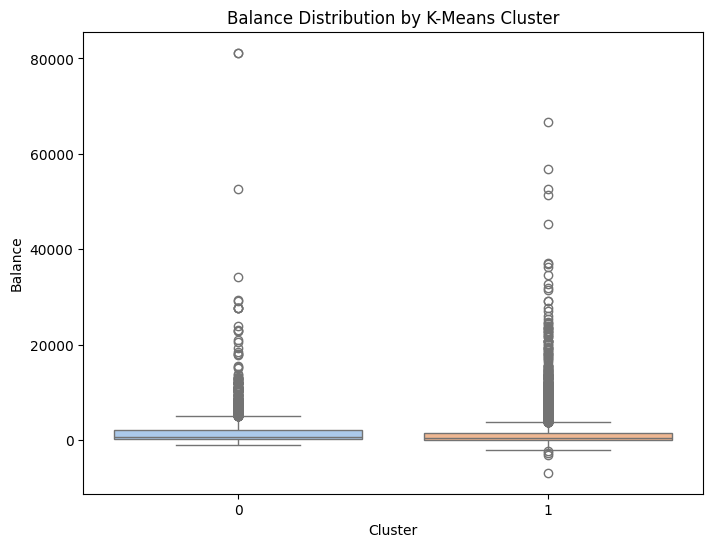

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(
    x=df_dummy['cluster'],   # K-Means cluster
    y=data['balance'],       # customer balance
    palette='pastel'
)
plt.title("Balance Distribution by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Balance")
plt.show()


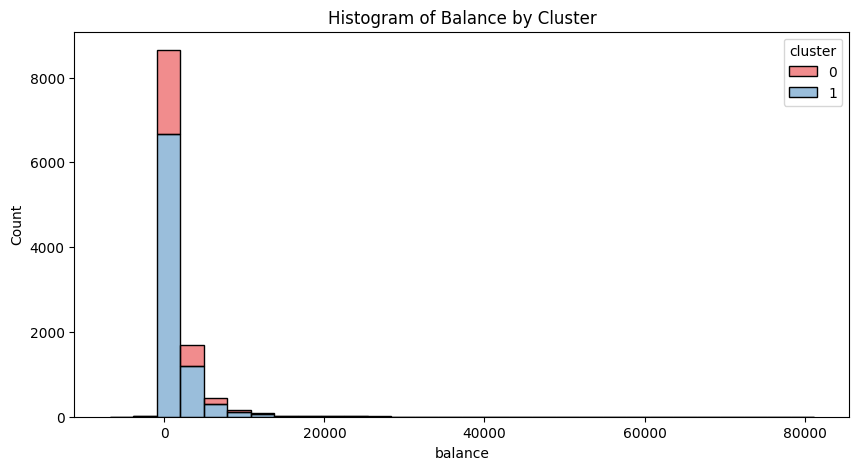

In [41]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=data,
    x='balance',
    hue=df_dummy['cluster'],
    bins=30,
    palette='Set1',
    alpha=0.5,
    multiple='stack'
)
plt.title("Histogram of Balance by Cluster")
plt.show()

Mean of Balance


In [49]:
data['balance']

,balance
0,2343
1,45
2,1270
3,2476
4,184
...,...
11157,1
11158,733
11159,29
11160,0


In [61]:
from numpy import average
averageofbalance = data['balance'].mean()

In [62]:
print(f'average of balance : {averageofbalance :.2f} Bath')

average of balance : 1528.54 Bath


In [64]:
data['balance'].describe()

,balance
count,11162.000000
mean,1528.538524
std,3225.413326
min,-6847.000000
25%,122.000000
50%,550.000000
75%,1708.000000
max,81204.000000


In [65]:
count_negative = len(data[data['balance'] < 0])
total_count = len(data)

print(f"จำนวนคนที่มี balance ติดลบ: {count_negative} คน")
print(f"คิดเป็น: {(count_negative/total_count)*100:.2f}% ของข้อมูลทั้งหมด")

จำนวนคนที่มี balance ติดลบ: 688 คน
คิดเป็น: 6.16% ของข้อมูลทั้งหมด


/tmp/ipython-input-3713296211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


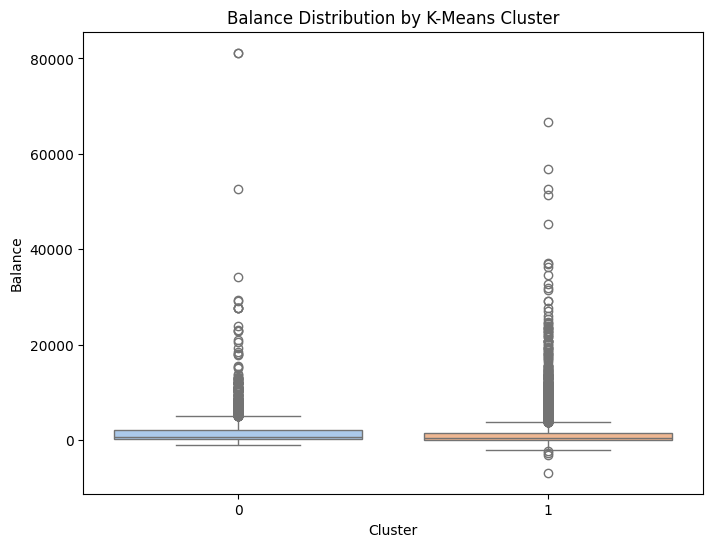

In [44]:


plt.figure(figsize=(8,6))
sns.boxplot(
    x=df_dummy['cluster'],  # คลัสเตอร์จาก K-Means
    y=data['balance'],      # ค่า balance จริง
    palette='pastel'
)
plt.title("Balance Distribution by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Balance")
plt.show()


/tmp/ipython-input-3955426220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


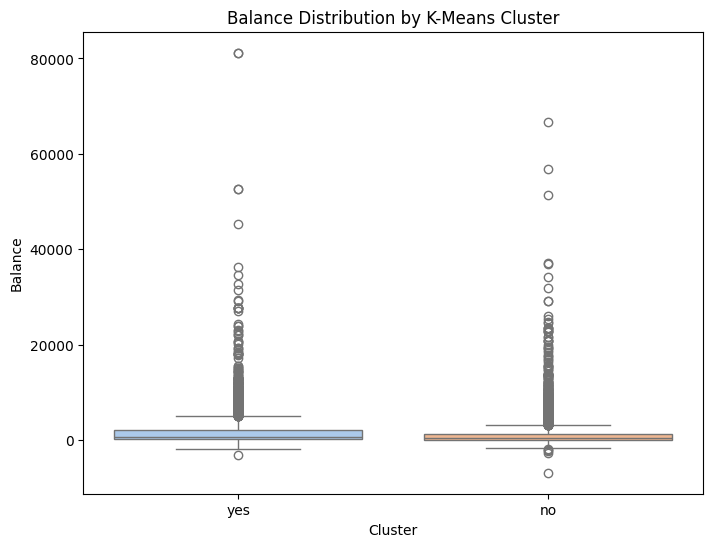

In [43]:


plt.figure(figsize=(8,6))
sns.boxplot(
    x=data['deposit'],  # คลัสเตอร์จาก K-Means
    y=data['balance'],      # ค่า balance จริง
    palette='pastel'
)
plt.title("Balance Distribution by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Balance")
plt.show()